#Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

#Create Policy Sales Dataset

total no. of policies

In [2]:
n = 1000000

create customer IDs

In [3]:
customer_ids = ["CUST_" + str(i) for i in range(1, n+1)]

create vehcile IDs

In [4]:
vehicle_ids = ["VEH_" + str(i) for i in range(1, n+1)]

  vehcile value

In [5]:
vehicle_values = [100000] * n

Generate Policy Tenure Distribution

In [6]:
policy_tenure = np.random.choice(
    [1,2,3,4],
    size=n,
    p=[0.2,0.3,0.4,0.1]
)

calculate premium

In [7]:
premium = policy_tenure * 100

Generate Policy Purchase Dates (2024)

In [8]:
start_date = datetime(2024,1,1)

purchase_dates = [
    start_date + timedelta(days=np.random.randint(0,365))
    for _ in range(n)
]

Policy Start and End Date

In [9]:
policy_start_dates = [
    d + timedelta(days=365) for d in purchase_dates
]

In [10]:
policy_end_dates = [
    policy_start_dates[i] + timedelta(days=int(policy_tenure[i]*365))
    for i in range(n)
]

Create Policy Sales Dataset

In [11]:
policy_df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Vehicle_ID": vehicle_ids,
    "Vehicle_Value": vehicle_values,
    "Premium": premium,
    "Policy_Purchase_Date": purchase_dates,
    "Policy_Start_Date": policy_start_dates,
    "Policy_End_Date": policy_end_dates,
    "Policy_Tenure": policy_tenure
})

In [12]:
policy_df.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,CUST_1,VEH_1,100000,100,2024-04-20,2025-04-20,2026-04-20,1
1,CUST_2,VEH_2,100000,300,2024-03-14,2025-03-14,2028-03-13,3
2,CUST_3,VEH_3,100000,100,2024-05-27,2025-05-27,2026-05-27,1
3,CUST_4,VEH_4,100000,300,2024-08-02,2025-08-02,2028-08-01,3
4,CUST_5,VEH_5,100000,200,2024-01-27,2025-01-26,2027-01-26,2


Save Policy Sales Dataset

In [22]:
policy_df.to_csv("policy_sales_data.csv", index=False)

#Create Claim Dataset

Select Vehicles Purchased on Special Dates

In [23]:
special_days = [7,14,21,28]

eligible = policy_df[
    policy_df["Policy_Purchase_Date"].dt.day.isin(special_days)
]

30% of These Vehicles File Claims

In [15]:
claims_2025 = eligible.sample(frac=0.30, random_state=1)

Create Claim Data

In [16]:
claims_2025 = claims_2025.copy()

claims_2025["Claim_ID"] = [
    "CLM_" + str(i) for i in range(1, len(claims_2025)+1)
]

claims_2025["Claim_Amount"] = 10000

claims_2025["Claim_Date"] = claims_2025["Policy_Start_Date"]

claims_2025["Claim_Type"] = 1

Select Required Columns

In [17]:
claims_df = claims_2025[[
    "Claim_ID",
    "Customer_ID",
    "Vehicle_ID",
    "Claim_Amount",
    "Claim_Date",
    "Claim_Type"
]]

In [18]:
claims_df.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
765750,CLM_1,CUST_765751,VEH_765751,10000,2025-11-21,1
702686,CLM_2,CUST_702687,VEH_702687,10000,2025-04-28,1
316141,CLM_3,CUST_316142,VEH_316142,10000,2025-10-21,1
27789,CLM_4,CUST_27790,VEH_27790,10000,2025-09-21,1
824188,CLM_5,CUST_824189,VEH_824189,10000,2025-07-28,1


Save Claim Dataset

In [19]:
claims_df.to_csv("claims_data.csv", index=False)

#Files of both Policy Sales & Claim Dataset

In [52]:
policy_sales_data.csv
claims_data.csv

NameError: name 'policy_sales_data' is not defined

In [25]:
policy = pd.read_csv("policy_sales_data.csv")
claims = pd.read_csv("claims_data.csv")

In [26]:
policy.head()
claims.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CLM_1,CUST_765751,VEH_765751,10000,2025-11-21,1
1,CLM_2,CUST_702687,VEH_702687,10000,2025-04-28,1
2,CLM_3,CUST_316142,VEH_316142,10000,2025-10-21,1
3,CLM_4,CUST_27790,VEH_27790,10000,2025-09-21,1
4,CLM_5,CUST_824189,VEH_824189,10000,2025-07-28,1


In [27]:
pd.read_csv("policy_sales_data.csv")

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,CUST_1,VEH_1,100000,100,2024-04-20,2025-04-20,2026-04-20,1
1,CUST_2,VEH_2,100000,300,2024-03-14,2025-03-14,2028-03-13,3
2,CUST_3,VEH_3,100000,100,2024-05-27,2025-05-27,2026-05-27,1
3,CUST_4,VEH_4,100000,300,2024-08-02,2025-08-02,2028-08-01,3
4,CUST_5,VEH_5,100000,200,2024-01-27,2025-01-26,2027-01-26,2
...,...,...,...,...,...,...,...,...
999995,CUST_999996,VEH_999996,100000,300,2024-04-19,2025-04-19,2028-04-18,3
999996,CUST_999997,VEH_999997,100000,300,2024-02-29,2025-02-28,2028-02-28,3
999997,CUST_999998,VEH_999998,100000,300,2024-03-20,2025-03-20,2028-03-19,3
999998,CUST_999999,VEH_999999,100000,100,2024-09-04,2025-09-04,2026-09-04,1


#Analytical Queries

load the datasets

In [30]:
import pandas as pd

policy = pd.read_csv("policy_sales_data.csv")
claims = pd.read_csv("claims_data.csv")

In [32]:
policy.head()

,Customer_ID,Vehicle_ID,Vehicle_Value,Premium,Policy_Purchase_Date,Policy_Start_Date,Policy_End_Date,Policy_Tenure
0,CUST_1,VEH_1,100000,100,2024-04-20,2025-04-20,2026-04-20,1
1,CUST_2,VEH_2,100000,300,2024-03-14,2025-03-14,2028-03-13,3
2,CUST_3,VEH_3,100000,100,2024-05-27,2025-05-27,2026-05-27,1
3,CUST_4,VEH_4,100000,300,2024-08-02,2025-08-02,2028-08-01,3
4,CUST_5,VEH_5,100000,200,2024-01-27,2025-01-26,2027-01-26,2


In [33]:
claims.head()

,Claim_ID,Customer_ID,Vehicle_ID,Claim_Amount,Claim_Date,Claim_Type
0,CLM_1,CUST_765751,VEH_765751,10000,2025-11-21,1
1,CLM_2,CUST_702687,VEH_702687,10000,2025-04-28,1
2,CLM_3,CUST_316142,VEH_316142,10000,2025-10-21,1
3,CLM_4,CUST_27790,VEH_27790,10000,2025-09-21,1
4,CLM_5,CUST_824189,VEH_824189,10000,2025-07-28,1


convert data columns

In [35]:
policy["Policy_Purchase_Date"] = pd.to_datetime(policy["Policy_Purchase_Date"])
policy["Policy_Start_Date"] = pd.to_datetime(policy["Policy_Start_Date"])
policy["Policy_End_Date"] = pd.to_datetime(policy["Policy_End_Date"])

claims["Claim_Date"] = pd.to_datetime(claims["Claim_Date"])

#  Q1. Calculate the total premium collected during the year 2024

In [36]:
total_premium = policy["Premium"].sum()
print("Total Premium Collected:", total_premium)

Total Premium Collected: 239993600


## Q2. Calculate the total claim cost for each year (2025 and 2026) with a monthly breakdown.

add year and month column

In [37]:
claims["Year"] = claims["Claim_Date"].dt.year
claims["Month"] = claims["Claim_Date"].dt.month

now calculate monthly claims

In [38]:
monthly_claims = claims.groupby(["Year","Month"])["Claim_Amount"].sum()
print(monthly_claims)

Year  Month
2025  1        33220000
      2        32540000
      3        32750000
      4        32980000
      5        32370000
      6        32560000
      7        32600000
      8        33420000
      9        32650000
      10       32930000
      11       32120000
      12       32600000
Name: Claim_Amount, dtype: int64


  ## Q3. Calculate the claim cost to premium ratio for each policy tenure (1, 2, 3, and 4 years).

merging dataset

In [39]:
merged = pd.merge(policy, claims, on=["Customer_ID","Vehicle_ID"])

now calculate

In [40]:
ratio = merged.groupby("Policy_Tenure").agg(
    Total_Claims=("Claim_Amount","sum"),
    Total_Premium=("Premium","sum")
)

ratio["Claim_to_Premium_Ratio"] = ratio["Total_Claims"] / ratio["Total_Premium"]

print(ratio)

               Total_Claims  Total_Premium  Claim_to_Premium_Ratio
Policy_Tenure                                                     
1                  77100000         771000              100.000000
2                 117800000        2356000               50.000000
3                 157800000        4734000               33.333333
4                  40040000        1601600               25.000000


## Q4.  Calculate the claim cost to premium ratio by the month in which the policy was sold(Jan–Dec 2024).


extract month

In [41]:
policy["Sale_Month"] = policy["Policy_Purchase_Date"].dt.month

merge

In [42]:
merged = pd.merge(policy, claims, on=["Customer_ID","Vehicle_ID"])

calculating ratio

In [43]:
monthly_ratio = merged.groupby("Sale_Month").agg(
    Claims=("Claim_Amount","sum"),
    Premium=("Premium","sum")
)

monthly_ratio["Ratio"] = monthly_ratio["Claims"] / monthly_ratio["Premium"]

print(monthly_ratio)

              Claims  Premium      Ratio
Sale_Month                              
1           33220000   793000  41.891551
2           32540000   780800  41.675205
3           32750000   795200  41.184608
4           32980000   790400  41.725709
5           32370000   787700  41.094325
6           32560000   784900  41.482991
7           32600000   783100  41.629422
8           33420000   805900  41.469165
9           32650000   786700  41.502479
10          32930000   797500  41.291536
11          32120000   768800  41.779396
12          32600000   788600  41.339082


## Q5.  If every vehicle that has not yet made a claim eventually files exactly one claim during theremaining policy tenure, estimate the total potential claim liability

Potential Future Claim Liability

Count vehciles without claims

In [53]:
claimed_vehicles = claims["Vehicle_ID"].unique()

no_claim = policy[~policy["Vehicle_ID"].isin(claimed_vehicles)]

future_liability = len(no_claim) * 10000

print("Estimated Future Claim Liability:", future_liability)

Estimated Future Claim Liability: 9607260000


## Q6.  Assume daily premium = Total Premium ÷ Total Policy Tenure Days. Based on this:
         Calculate the premium already earned by the company up to February 28, 2026.
         Estimate the premium expected to be earned monthly for the remaining policy period (assume 46 months remaining).

calculate total policy days

In [45]:
policy["Policy_Days"] = (
    policy["Policy_End_Date"] - policy["Policy_Start_Date"]
).dt.days

daily premium :

In [46]:
policy["Daily_Premium"] = policy["Premium"] / policy["Policy_Days"]

earned premium :

In [47]:
cutoff = pd.to_datetime("2026-02-28")

policy["Earned_Days"] = (cutoff - policy["Policy_Start_Date"]).dt.days
policy["Earned_Days"] = policy["Earned_Days"].clip(lower=0)

policy["Earned_Premium"] = policy["Daily_Premium"] * policy["Earned_Days"]

earned_premium = policy["Earned_Premium"].sum()

print("Premium Earned until Feb 28 2026:", earned_premium)

Premium Earned until Feb 28 2026: 66322087.945205495


# Monthly Claim Cost Chart 

In [67]:
import matplotlib.pyplot as plt

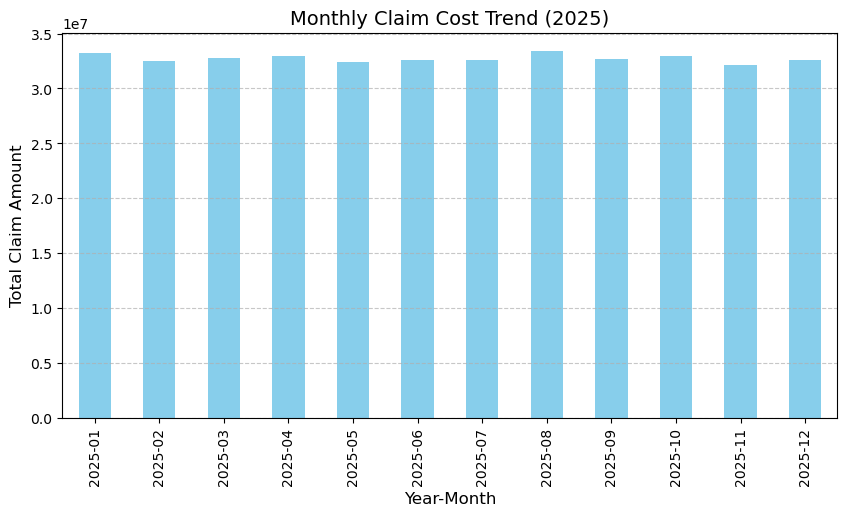

In [70]:
monthly_claims.plot(
    kind="bar",
    color="skyblue",
    figsize=(10,5)
)

plt.title("Monthly Claim Cost Trend (2025)", fontsize=14)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Claim Amount", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

# Premium vs Claims Chart

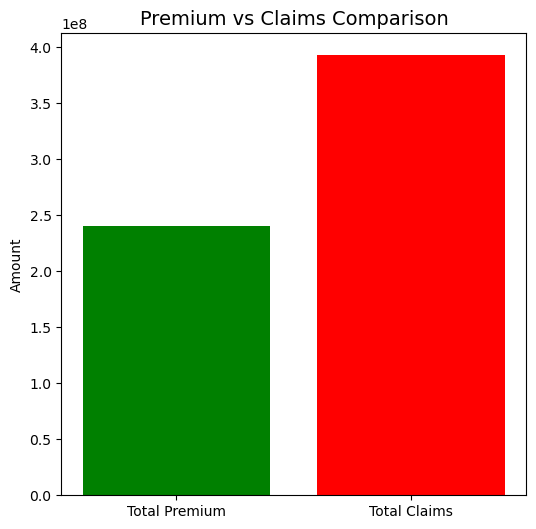

In [55]:
premium_total = policy_df["Premium"].sum()
claims_total = claims_df["Claim_Amount"].sum()

data = [premium_total, claims_total]
labels = ["Total Premium", "Total Claims"]

plt.figure(figsize=(6,6))

plt.bar(labels, data, color=["green","red"])

plt.title("Premium vs Claims Comparison", fontsize=14)
plt.ylabel("Amount")

plt.show()

##### Interpretation:
      Green -> company revenue
      Red -> claim payouts

# Policy Tenure Distribution Chart

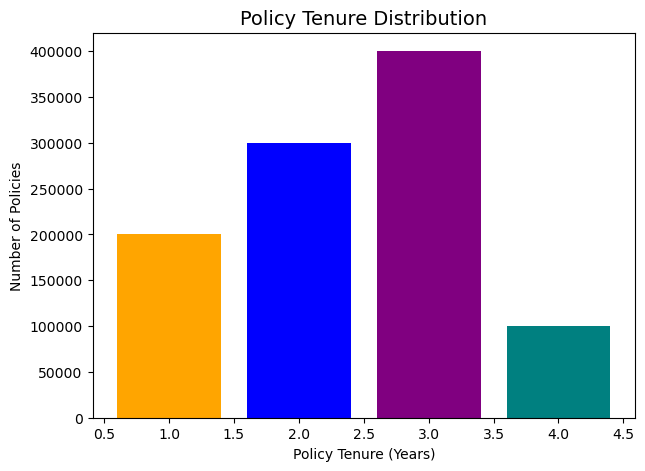

In [56]:
tenure_counts = policy_df["Policy_Tenure"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    tenure_counts.index,
    tenure_counts.values,
    color=["orange","blue","purple","teal"]
)

plt.title("Policy Tenure Distribution", fontsize=14)
plt.xlabel("Policy Tenure (Years)")
plt.ylabel("Number of Policies")

plt.show()

# Claim Ratio by Tenure

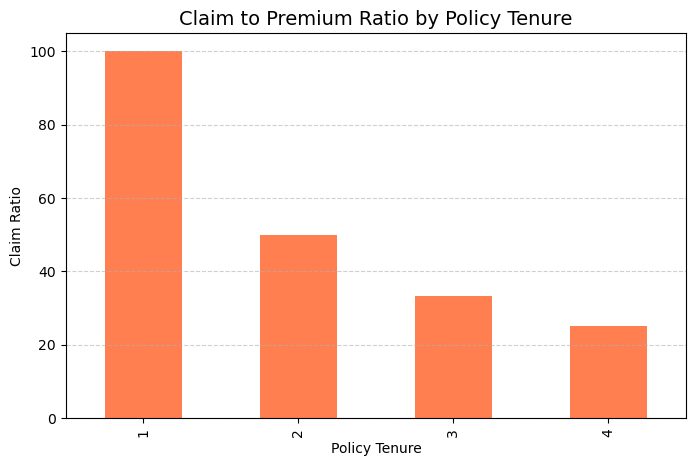

In [57]:
ratio["Claim_to_Premium_Ratio"].plot(
    kind="bar",
    color="coral",
    figsize=(8,5)
)

plt.title("Claim to Premium Ratio by Policy Tenure", fontsize=14)
plt.xlabel("Policy Tenure")
plt.ylabel("Claim Ratio")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

### Claim Trends Dashboard

In [62]:
claims_df["Claim_Date"] = pd.to_datetime(claims_df["Claim_Date"])

claims_df["Month"] = claims_df["Claim_Date"].dt.to_period("M")

monthly_claims = claims_df.groupby("Month")["Claim_Amount"].sum()

print(monthly_claims)

Month
2025-01    33220000
2025-02    32540000
2025-03    32750000
2025-04    32980000
2025-05    32370000
2025-06    32560000
2025-07    32600000
2025-08    33420000
2025-09    32650000
2025-10    32930000
2025-11    32120000
2025-12    32600000
Freq: M, Name: Claim_Amount, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_11936\2002135162.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  claims_df["Claim_Date"] = pd.to_datetime(claims_df["Claim_Date"])
C:\Users\user\AppData\Local\Temp\ipykernel_11936\2002135162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  claims_df["Month"] = claims_df["Claim_Date"].dt.to_period("M")


## Monthly Claim Trend Visualization

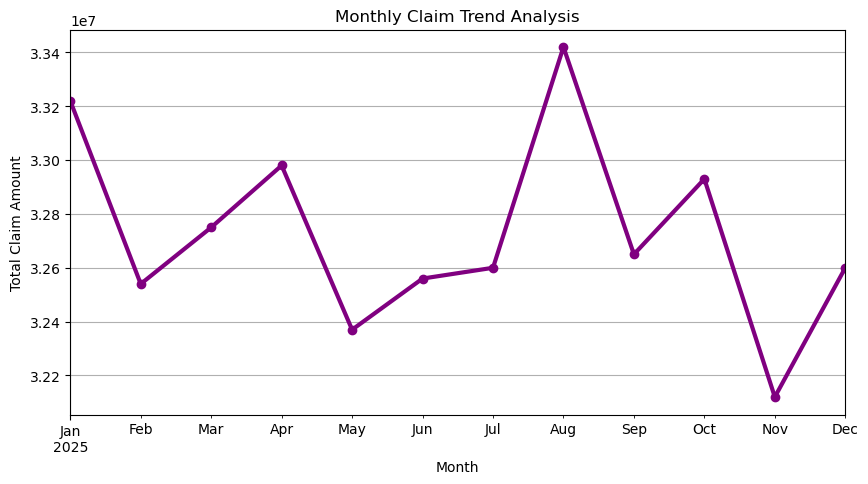

In [63]:
monthly_claims.plot(
    kind="line",
    marker="o",
    color="purple",
    linewidth=3,
    figsize=(10,5)
)

plt.title("Monthly Claim Trend Analysis")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount")
plt.grid(True)

plt.show()

# Loss Ratio 
   Loss Ratio is a key insurance KPI used to measure profitability.

         Loss Ratio = Total Claims / Total Premium

In [75]:
total_premium = policy_df["Premium"].sum()
total_claims = claims_df["Claim_Amount"].sum()

loss_ratio = total_claims / total_premium

print("Total Premium Collected:", total_premium)
print("Total Claims Paid:", total_claims)
print("Loss Ratio:", round(loss_ratio,2))

Total Premium Collected: 239993600
Total Claims Paid: 392740000
Loss Ratio: 1.64


### Loss Ratio - 1.64
    Interpretation: 
    < 1	Portfolio is profitable
    = 1	Break-even
    > 1	Portfolio is losing money

    A lower loss ratio indicates better financial performance for the insurance company.

## Future Profitability Simulation (5% Claim Increase)

### Business Objective
    Estimate how future claim growth may impact profitability.

In [65]:
# Simulate 5% increase in claims
future_claims = total_claims * 1.05

# Recalculate loss ratio
future_loss_ratio = future_claims / total_premium

print("Projected Claims (Next Year):", future_claims)
print("Projected Loss Ratio:", round(future_loss_ratio,2))

Projected Claims (Next Year): 412377000.0
Projected Loss Ratio: 1.72


### Visualization
    Impact of 5% Increase in Claim Frequency

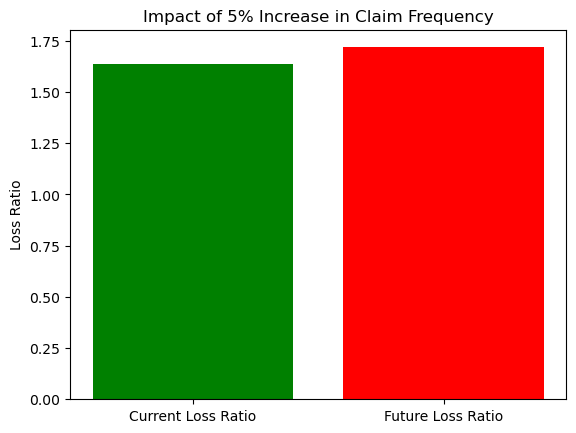

In [66]:
values = [loss_ratio, future_loss_ratio]
labels = ["Current Loss Ratio","Future Loss Ratio"]

plt.bar(labels, values, color=["green","red"])

plt.title("Impact of 5% Increase in Claim Frequency")
plt.ylabel("Loss Ratio")

plt.show()

### Insight
    If claim frequency increases by 5% annually:
    -  The loss ratio will rise
    -  Profit margins will decline
    -  The company may need to:
          Adjust premium pricing
          Improve underwriting practices
          Enhance fraud detection systems.